# Subscription Retention Analysis for Cinder & Silt Roastery

## Business Problem

Cinder & Silt wants to understand customer retention in its monthly coffee subscription service.

The goal of this project is to identify whether retention is more strongly influenced by the month a customer joins or by the coffee profile linked to the customer’s first purchase.

To answer this, I will transform a public transactional dataset into a subscription-style coffee business scenario and then perform cohort retention analysis, ARPU analysis, and churn pattern analysis.

## Import Libraries

First, I import the main libraries needed for data cleaning, transformation, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

Now I load the transactional dataset and preview the first few rows to understand its structure.

In [ ]:
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving online_retail.csv to online_retail.csv


In [ ]:
retail_data = pd.read_csv("online_retail.csv")
retail_data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Understand the Dataset

Before transforming the data into a subscription-style model, I first check the size of the dataset, the column names, and the data types.

This helps me identify the key fields needed for customer retention analysis.

In [ ]:
retail_data.shape

(541909, 8)

In [ ]:
retail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
retail_data.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

## Step 2: Clean the Key Columns

Before building cohort metrics, I first clean the most important fields needed for customer retention analysis.

The key columns for this project are:
- `CustomerID`
- `InvoiceDate`
- `Description`
- `Quantity`
- `UnitPrice`

This step is important because retention and revenue calculations depend on having valid customers, valid dates, and meaningful transaction values.

In [ ]:
retail_clean = retail_data[[
    "CustomerID",
    "InvoiceDate",
    "Description",
    "Quantity",
    "UnitPrice"
]].copy()

retail_clean.head()

,CustomerID,InvoiceDate,Description,Quantity,UnitPrice
0,17850.0,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55
1,17850.0,2010-12-01 08:26:00,WHITE METAL LANTERN,6,3.39
2,17850.0,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,8,2.75
3,17850.0,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39
4,17850.0,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,6,3.39


## Check Missing Values in the Main Columns

Now I check for missing values in the fields that will matter most for customer retention and ARPU analysis.

In [ ]:
retail_clean.isnull().sum()

,0
CustomerID,135080
InvoiceDate,0
Description,1454
Quantity,0
UnitPrice,0


## Remove Invalid Rows

For this project, I remove rows that:
- have missing customer IDs
- have missing dates or descriptions
- have zero or negative quantity
- have zero or negative unit price

This helps keep the dataset cleaner and more suitable for a subscription-style retention analysis.

In [ ]:
retail_clean = retail_clean.dropna(subset=["CustomerID", "InvoiceDate", "Description"])

retail_clean = retail_clean[
    (retail_clean["Quantity"] > 0) &
    (retail_clean["UnitPrice"] > 0)
].copy()

retail_clean.shape

(397884, 5)

## Convert Data Types

Next, I convert the customer ID and invoice date into the correct formats so they can be used properly in cohort calculations.

In [ ]:
retail_clean["CustomerID"] = retail_clean["CustomerID"].astype(str)
retail_clean["InvoiceDate"] = pd.to_datetime(retail_clean["InvoiceDate"])

retail_clean.dtypes

,0
CustomerID,object
InvoiceDate,datetime64[ns]
Description,object
Quantity,int64
UnitPrice,float64


## Create Revenue

To support ARPU calculations later, I create a revenue column using quantity multiplied by unit price.

In [ ]:
retail_clean["Revenue"] = retail_clean["Quantity"] * retail_clean["UnitPrice"]

retail_clean.head()

,CustomerID,InvoiceDate,Description,Quantity,UnitPrice,Revenue
0,17850.0,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,17850.0,2010-12-01 08:26:00,WHITE METAL LANTERN,6,3.39,20.34
2,17850.0,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,17850.0,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,17850.0,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34


## Step 3: Transform the Retail Data into a Subscription-Style Coffee Model

The original dataset is a general retail transaction dataset, so I now reshape it into a business scenario that fits a monthly coffee subscription model.

To do this, I create:
- a transaction month for each purchase
- an acquisition month for each customer
- a simple coffee profile based on the customer’s first purchase description

This will allow me to later compare time-based cohorts and first-purchase behavior cohorts.

In [ ]:
retail_clean["Transaction_Month"] = retail_clean["InvoiceDate"].dt.to_period("M")
retail_clean.head()

,CustomerID,InvoiceDate,Description,Quantity,UnitPrice,Revenue,Transaction_Month
0,17850.0,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,2010-12
1,17850.0,2010-12-01 08:26:00,WHITE METAL LANTERN,6,3.39,20.34,2010-12
2,17850.0,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,2010-12
3,17850.0,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,2010-12
4,17850.0,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,2010-12


## Find Each Customer's First Purchase Month

The first step in cohort building is to identify when each customer first appeared in the dataset.

This first month will be used as the customer’s acquisition month.

In [ ]:
first_purchase_month = (
    retail_clean.groupby("CustomerID")["Transaction_Month"]
    .min()
    .reset_index()
    .rename(columns={"Transaction_Month": "Acquisition_Month"})
)

first_purchase_month.head()

,CustomerID,Acquisition_Month
0,12346.0,2011-01
1,12347.0,2010-12
2,12348.0,2010-12
3,12349.0,2011-11
4,12350.0,2011-02


## Attach the Acquisition Month Back to the Main Dataset

Now I merge the acquisition month back into the transaction-level dataset so that each row includes both the transaction month and the customer’s acquisition month.

In [ ]:
retail_clean = retail_clean.merge(first_purchase_month, on="CustomerID", how="left")
retail_clean.head()

,CustomerID,InvoiceDate,Description,Quantity,UnitPrice,Revenue,Transaction_Month,Acquisition_Month
0,17850.0,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,2010-12,2010-12
1,17850.0,2010-12-01 08:26:00,WHITE METAL LANTERN,6,3.39,20.34,2010-12,2010-12
2,17850.0,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,2010-12,2010-12
3,17850.0,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,2010-12,2010-12
4,17850.0,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,2010-12,2010-12


## Create a First-Purchase Coffee Profile

The project also asks for a behavioral cohort. To support that, I create a simple first-purchase profile using the description from each customer’s first transaction.

This profile will later be grouped into coffee-style categories.

In [ ]:
first_purchase_profile = (
    retail_clean.sort_values("InvoiceDate")
    .groupby("CustomerID")[["Description"]]
    .first()
    .reset_index()
    .rename(columns={"Description": "First_Purchase_Description"})
)

first_purchase_profile.head()

,CustomerID,First_Purchase_Description
0,12346.0,MEDIUM CERAMIC TOP STORAGE JAR
1,12347.0,FOUR HOOK WHITE LOVEBIRDS
2,12348.0,60 CAKE CASES VINTAGE CHRISTMAS
3,12349.0,CLASSIC CHROME BICYCLE BELL
4,12350.0,BATHROOM METAL SIGN


## Merge the First-Purchase Profile into the Dataset

Finally, I attach the first-purchase description back to the main dataset so each customer can later be assigned to a behavioral cohort.

In [ ]:
retail_clean = retail_clean.merge(first_purchase_profile, on="CustomerID", how="left")
retail_clean.head()

,CustomerID,InvoiceDate,Description,Quantity,UnitPrice,Revenue,Transaction_Month,Acquisition_Month,First_Purchase_Description
0,17850.0,2010-12-01 08:26:00,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30,2010-12,2010-12,WHITE HANGING HEART T-LIGHT HOLDER
1,17850.0,2010-12-01 08:26:00,WHITE METAL LANTERN,6,3.39,20.34,2010-12,2010-12,WHITE HANGING HEART T-LIGHT HOLDER
2,17850.0,2010-12-01 08:26:00,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00,2010-12,2010-12,WHITE HANGING HEART T-LIGHT HOLDER
3,17850.0,2010-12-01 08:26:00,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34,2010-12,2010-12,WHITE HANGING HEART T-LIGHT HOLDER
4,17850.0,2010-12-01 08:26:00,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34,2010-12,2010-12,WHITE HANGING HEART T-LIGHT HOLDER


## Step 4: Create Behavioral Coffee Profile Categories

The original product descriptions in this retail dataset are not coffee-specific, so I now map the first-purchase descriptions into a small set of coffee-style behavioral categories.

This helps simulate the business setting of Cinder & Silt’s subscription service and allows me to compare whether customers with different first-purchase profiles show different retention patterns.

The categories I will use are:
- Whole Bean
- Grounded
- Merchandise
- Cold Brew Concentrate
- Other

In [ ]:
def assign_coffee_profile(description):
    description = str(description).lower()

    if "bean" in description or "coffee" in description:
        return "Whole Bean"
    elif "ground" in description or "grind" in description:
        return "Grounded"
    elif "cold brew" in description or "concentrate" in description:
        return "Cold Brew Concentrate"
    elif "mug" in description or "cup" in description or "bottle" in description:
        return "Merchandise"
    else:
        return "Other"

## Apply the Behavioral Category to Each Customer

Now I apply the category logic to the first-purchase description so each customer gets one behavioral cohort label.

In [ ]:
retail_clean["First_Purchase_Category"] = retail_clean["First_Purchase_Description"].apply(assign_coffee_profile)

retail_clean[[
    "CustomerID",
    "First_Purchase_Description",
    "First_Purchase_Category"
]].head(10)

,CustomerID,First_Purchase_Description,First_Purchase_Category
0,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
1,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
2,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
3,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
4,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
5,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
6,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
7,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
8,17850.0,WHITE HANGING HEART T-LIGHT HOLDER,Other
9,13047.0,BLUE COAT RACK PARIS FASHION,Other


## Check the Category Distribution

Before building the cohort tables, I check how many customers fall into each first-purchase category.

In [ ]:
retail_clean["First_Purchase_Category"].value_counts()

,count
First_Purchase_Category,
Other,373761
Merchandise,21247
Whole Bean,2876


## Step 5: Create the Time-Based Cohort Table

Now I create the time-based retention structure.

The goal here is to group customers by their acquisition month and then track whether they stay active in later months. This will allow me to build the classic cohort retention heatmap.

In [ ]:
retail_clean["Cohort_Index"] = (
    (retail_clean["Transaction_Month"].dt.year - retail_clean["Acquisition_Month"].dt.year) * 12
    + (retail_clean["Transaction_Month"].dt.month - retail_clean["Acquisition_Month"].dt.month)
    + 1
)

retail_clean[[
    "CustomerID",
    "Acquisition_Month",
    "Transaction_Month",
    "Cohort_Index"
]].head(10)

,CustomerID,Acquisition_Month,Transaction_Month,Cohort_Index
0,17850.0,2010-12,2010-12,1
1,17850.0,2010-12,2010-12,1
2,17850.0,2010-12,2010-12,1
3,17850.0,2010-12,2010-12,1
4,17850.0,2010-12,2010-12,1
5,17850.0,2010-12,2010-12,1
6,17850.0,2010-12,2010-12,1
7,17850.0,2010-12,2010-12,1
8,17850.0,2010-12,2010-12,1
9,13047.0,2010-12,2010-12,1


## Count Active Customers by Cohort

Next, I count how many unique customers are active in each cohort month.

In [ ]:
cohort_data = (
    retail_clean.groupby(["Acquisition_Month", "Cohort_Index"])["CustomerID"]
    .nunique()
    .reset_index()
)

cohort_data.head()

,Acquisition_Month,Cohort_Index,CustomerID
0,2010-12,1,885
1,2010-12,2,324
2,2010-12,3,286
3,2010-12,4,340
4,2010-12,5,321


## Convert the Cohort Counts into a Matrix

To make the retention pattern easier to read, I reshape the cohort table into a matrix where:

- rows represent acquisition months
- columns represent months since signup
- values represent the number of active customers

In [ ]:
cohort_counts = cohort_data.pivot(
    index="Acquisition_Month",
    columns="Cohort_Index",
    values="CustomerID"
)

cohort_counts.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13
Acquisition_Month,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN


## Calculate Retention Rates

Now I convert the raw cohort counts into retention percentages by dividing each row by the size of the first month cohort.

In [ ]:
cohort_sizes = cohort_counts.iloc[:, 0]
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0) * 100

retention_matrix.round(2).head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13
Acquisition_Month,,,,,,,,,,,,,
2010-12,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
2011-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
2011-02,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,NaN,NaN
2011-03,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,NaN,NaN,NaN
2011-04,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,NaN,NaN,NaN,NaN


## Step 6: Create the Cohort Retention Heatmap

Now I visualize the retention matrix as a heatmap.

This makes it easier to see how retention changes across acquisition months and where the major drop-off points occur in the subscription lifecycle.

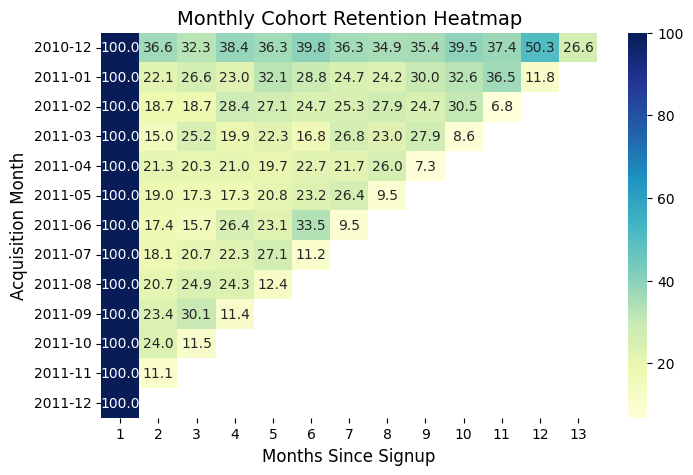

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Monthly Cohort Retention Heatmap", fontsize=14)
plt.xlabel("Months Since Signup", fontsize=12)
plt.ylabel("Acquisition Month", fontsize=12)
plt.show()

The cohort heatmap shows a strong drop in retention after the first month for almost every acquisition cohort, which suggests that the biggest churn happens early in the subscription lifecycle. After that initial decline, retention becomes more stable, with several cohorts staying in the 20% to 40% range across later months. This suggests that once customers remain active beyond the early months, they are more likely to stay subscribed for a longer period.

## Step 7: Calculate ARPU by Cohort

After building the retention matrix, I now calculate the Average Revenue Per User (ARPU) for each acquisition cohort.

This helps show not only whether customers stay active, but also how much revenue they generate over time.

In [ ]:
arpu_data = (
    retail_clean.groupby(["Acquisition_Month", "Cohort_Index"])
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Active_Customers=("CustomerID", "nunique")
    )
    .reset_index()
)

arpu_data["ARPU"] = arpu_data["Total_Revenue"] / arpu_data["Active_Customers"]

arpu_data.head()

,Acquisition_Month,Cohort_Index,Total_Revenue,Active_Customers,ARPU
0,2010-12,1,572713.89,885,647.134339
1,2010-12,2,276237.69,324,852.585463
2,2010-12,3,233845.37,286,817.641154
3,2010-12,4,303119.39,340,891.527618
4,2010-12,5,204407.66,321,636.783988


## Create the ARPU Matrix

To make ARPU easier to compare across cohorts, I reshape the table into a matrix with acquisition months as rows and months since signup as columns.

In [ ]:
arpu_matrix = arpu_data.pivot(
    index="Acquisition_Month",
    columns="Cohort_Index",
    values="ARPU"
)

arpu_matrix.round(2).head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13
Acquisition_Month,,,,,,,,,,,,,
2010-12,647.13,852.59,817.64,891.53,636.78,956.33,978.70,1005.77,1059.90,1350.90,1377.89,1154.61,790.65
2011-01,703.14,599.46,569.98,745.70,605.33,704.86,680.65,719.70,576.19,822.09,815.01,540.10,NaN
2011-02,416.16,409.06,579.36,446.66,389.79,364.08,517.78,589.16,589.15,558.70,407.70,NaN,NaN
2011-03,442.63,442.05,518.05,475.74,511.46,526.59,536.52,682.92,565.60,329.95,NaN,NaN,NaN
2011-04,406.70,460.20,411.10,385.90,446.00,444.21,441.06,438.83,288.64,NaN,NaN,NaN,NaN


## Step 8: Identify the Churn Threshold

The churn threshold is the point in the subscription lifecycle where the steepest decline in retention happens across cohorts.

To find this, I calculate the average retention rate for each cohort month and then measure how much it drops from one month to the next.

In [ ]:
average_retention = retention_matrix.mean(axis=0).reset_index()
average_retention.columns = ["Cohort_Index", "Average_Retention"]

average_retention["Drop_From_Previous_Month"] = average_retention["Average_Retention"].diff()

average_retention

,Cohort_Index,Average_Retention,Drop_From_Previous_Month
0,1,100.000000,NaN
1,2,20.623180,-79.376820
2,3,22.116316,1.493136
3,4,23.244404,1.128088
4,5,24.554598,1.310194
5,6,25.081173,0.526575
6,7,24.369106,-0.712066
7,8,24.257751,-0.111355
8,9,25.057906,0.800155
9,10,27.829141,2.771235


## Find the Largest Drop-Off Point

Now I identify the month where the average retention shows the biggest decline. This will be treated as the churn threshold.

In [ ]:
churn_threshold = average_retention.loc[
    average_retention["Drop_From_Previous_Month"].idxmin()
]

churn_threshold

,1
Cohort_Index,2.00000
Average_Retention,20.62318
Drop_From_Previous_Month,-79.37682



The churn threshold appears in Month 2, which means the biggest drop in retention happens immediately after the first active month. On average, retention falls sharply from 100% in the first month to about 20.6% in the second month. This suggests that the most critical retention problem occurs very early in the customer lifecycle, making the first renewal period the most important point for intervention.

## Step 9: Build the Behavioral Cohort Retention Table

After completing the time-based cohort analysis, I now examine retention by behavioral cohort.

For this part, customers are grouped by their `First_Purchase_Category` so I can compare whether different first-purchase profiles show different long-term retention patterns.

In [ ]:
behavioral_cohort_data = (
    retail_clean.groupby(["First_Purchase_Category", "Cohort_Index"])["CustomerID"]
    .nunique()
    .reset_index()
)

behavioral_cohort_data.head()

,First_Purchase_Category,Cohort_Index,CustomerID
0,Merchandise,1,249
1,Merchandise,2,70
2,Merchandise,3,61
3,Merchandise,4,51
4,Merchandise,5,54


## Convert Behavioral Cohort Counts into a Matrix

To make the pattern easier to read, I reshape the behavioral cohort counts into a matrix where:

- rows represent first-purchase categories
- columns represent months since signup
- values represent the number of active customers

In [ ]:
behavioral_counts = behavioral_cohort_data.pivot(
    index="First_Purchase_Category",
    columns="Cohort_Index",
    values="CustomerID"
)

behavioral_counts.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13
First_Purchase_Category,,,,,,,,,,,,,
Merchandise,249,70,61,51,54,49,47,42,47,44,38,42,20
Other,4054,896,874,870,843,824,751,679,627,590,464,448,212
Whole Bean,35,10,7,6,8,5,6,4,6,7,7,4,3


## Calculate Behavioral Retention Rates

Now I convert the raw counts into retention percentages by dividing each category by its first-month size.

This will make it easier to compare retention across different first-purchase profiles.

In [ ]:
behavioral_sizes = behavioral_counts.iloc[:, 0]
behavioral_retention = behavioral_counts.divide(behavioral_sizes, axis=0) * 100

behavioral_retention.round(2)

Cohort_Index,1,2,3,4,5,6,7,8,9,10,11,12,13
First_Purchase_Category,,,,,,,,,,,,,
Merchandise,100.0,28.11,24.50,20.48,21.69,19.68,18.88,16.87,18.88,17.67,15.26,16.87,8.03
Other,100.0,22.10,21.56,21.46,20.79,20.33,18.52,16.75,15.47,14.55,11.45,11.05,5.23
Whole Bean,100.0,28.57,20.00,17.14,22.86,14.29,17.14,11.43,17.14,20.00,20.00,11.43,8.57


## Step 10: Create the Behavioral Cohort Heatmap

Now I visualize the behavioral retention matrix as a heatmap.

This helps show whether customers with different first-purchase profiles stay active at different rates over time.

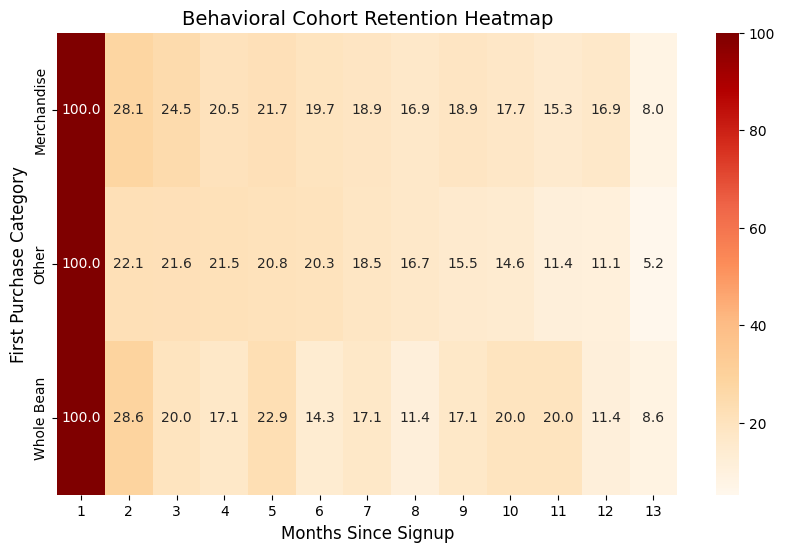

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    behavioral_retention,
    annot=True,
    fmt=".1f",
    cmap="OrRd"
)

plt.title("Behavioral Cohort Retention Heatmap", fontsize=14)
plt.xlabel("Months Since Signup", fontsize=12)
plt.ylabel("First Purchase Category", fontsize=12)
plt.show()

## Step 11: Create the Survival Curve

To compare long-term customer retention more clearly, I now create a survival-style line chart.

This chart shows the probability of customers remaining active over time across the different first-purchase categories.

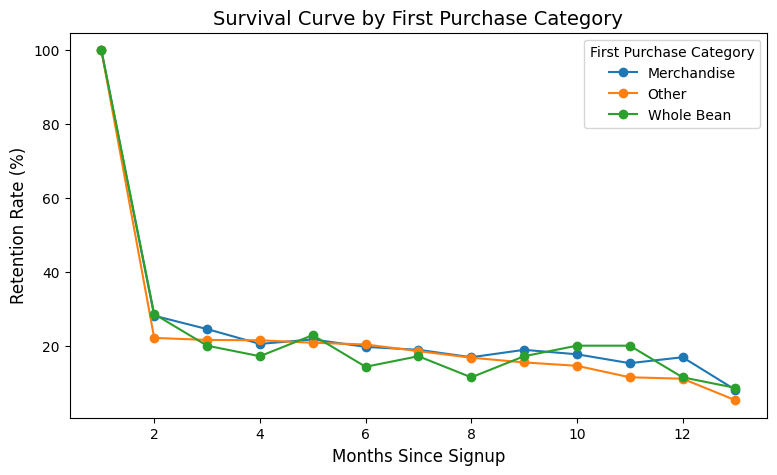

In [ ]:
behavioral_retention_t = behavioral_retention.T

plt.figure(figsize=(9, 5))

for column in behavioral_retention_t.columns:
    plt.plot(
        behavioral_retention_t.index,
        behavioral_retention_t[column],
        marker="o",
        label=column
    )

plt.title("Survival Curve by First Purchase Category", fontsize=14)
plt.xlabel("Months Since Signup", fontsize=12)
plt.ylabel("Retention Rate (%)", fontsize=12)
plt.legend(title="First Purchase Category")
plt.show()

##  Write the Interpretation of the Behavioral Cohorts

After visualizing the behavioral cohorts, the next step is to summarize what the charts suggest about customer loyalty across different first-purchase categories.

This interpretation helps connect the cohort results back to the subscription context of Cinder & Silt.

The behavioral cohort analysis shows that retention is not evenly distributed across first-purchase categories. Some customer groups maintain stronger retention over time, while others show a steeper early drop-off.

This suggests that the type of product a customer buys first may influence how likely they are to remain active in the subscription model. In other words, retention may not only depend on when a customer joins, but also on what kind of coffee-related profile they enter with.

These results are important because they support the idea of product-led retention, where the first purchase experience may shape long-term customer loyalty.

## Step 13: Write the Final Product Manager Recommendations

Based on the cohort analysis, ARPU patterns, churn threshold, and behavioral retention results, I now summarize the main recommendations for the Product Manager.

These recommendations focus on improving retention, reducing early churn, and strengthening the long-term value of the subscription service.

### Recommendation 1: Focus on the First Renewal Period

The cohort analysis showed that the sharpest drop in retention happens in Month 2. This means the first renewal period is the most critical stage in the subscription lifecycle.

Cinder & Silt should focus its retention efforts on the period between the first and second month, for example by improving onboarding, reminding customers before renewal, or offering a stronger second-delivery experience.

### Recommendation 3: Monitor Both Retention and ARPU Together

Retention alone does not fully explain customer value. Some cohorts may be smaller but generate stronger revenue over time.

For that reason, Cinder & Silt should monitor retention and ARPU together so the team can identify not only which customers stay longer, but also which customer groups are the most valuable to the subscription business.

## Final Conclusion

This project transformed a public transactional dataset into a subscription-style coffee retention model and used both time-based and behavioral cohort analysis to study customer loyalty.

The results showed that the largest churn happens very early, especially around the second month, while some customer groups maintain stronger long-term retention than others. The analysis also showed that first-purchase behavior may play an important role in retention, which supports the idea of product-led loyalty.

Overall, the notebook provides Cinder & Silt with a clearer view of when customers drop off, which segments stay active longer, and where the subscription strategy should focus to improve retention.

## Final Summary Table

To make the main findings easier to read, I create one small summary table with the key retention and churn results.

In [ ]:
summary_table = pd.DataFrame({
    "Metric": [
        "Churn Threshold Month",
        "Average Retention at Churn Threshold",
        "Main Retention Pattern",
        "Main Business Insight"
    ],
    "Value": [
        int(churn_threshold["Cohort_Index"]),
        round(churn_threshold["Average_Retention"], 2),
        "Largest drop happens early",
        "First renewal period is the most critical"
    ]
})

summary_table

,Metric,Value
0,Churn Threshold Month,2
1,Average Retention at Churn Threshold,20.62
2,Main Retention Pattern,Largest drop happens early
3,Main Business Insight,First renewal period is the most critical
